# Time series test

Experiment with the time series graph: compare the full dual-axis plot (message volume + avg word count) with a **volume-only** plot (no average message length).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from loguru import logger
import warnings
import os

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
import tomllib

configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)
config

{'raw': 'data/raw',
 'preprocessed': 'data/preprocessed',
 'cleaned': 'data/cleaned',
 'feature_added': 'data/feature_added',
 'processed': 'data/processed',
 'input': '_chat.txt',
 'current': 'whatsapp_current.parq',
 'preprocess_csv': 'whatsapp_preprocess.csv',
 'preprocess_parq': 'whatsapp_preprocess.parq',
 'cleaned_csv': 'whatsapp_cleaned.csv',
 'cleaned_parq': 'whatsapp_cleaned.parq',
 'feature_engineered_csv': 'whatsapp_feature.csv',
 'feature_engineered_parq': 'whatsapp_feature.parq',
 'time_series_plot_png': 'time_series_plot.png',
 'categories_plot_png': 'categories_plot.png',
 'distribution_plot_png': 'distribution_plot.png',
 'correlation_plot_png': 'correlation_plot.png',
 'dimensionality_plot_png': 'dimensionality_plot.png',
 'datetime_format': '%d-%m-%Y %H:%M',
 'drop_authors': []}

In [10]:
# First 10 records (run cells above to load df)
display(df.head(10))

,timestamp,message,living_in_city,living_with_partner,date_living_with_partner,tech_background,author,year,month,week,...,react_time_hr_log,is_question,mentions_meet_up,is_image,is_empty_message,is_removed_message,has_emoji,emoji_count,sentiment_polarity,sentiment_category
0,2022-09-16 07:31:00+00:00,Wachten op dit bericht,1,1,2023-06-01 00:00:00+00:00,1,spattered-duck,2022,9,37,...,NaN,0,0,0,1,0,0,0,0.0,Neutral
1,2022-09-16 07:41:00+00:00,Wachten op dit bericht,0,0,NaT,1,riotous-dingo,2022,9,37,...,0.154151,0,0,0,1,0,0,0,0.0,Neutral
2,2022-09-16 08:21:00+00:00,Wachten op dit bericht,0,1,2025-03-10 00:00:00+00:00,0,translucent-dog,2022,9,37,...,0.510826,0,0,0,1,0,0,0,0.0,Neutral
3,2022-09-16 08:23:00+00:00,Wachten op dit bericht,0,1,2024-11-01 00:00:00+00:00,0,hypnotic-rabbit,2022,9,37,...,0.032790,0,0,0,1,0,0,0,0.0,Neutral
4,2022-09-16 09:08:00+00:00,Wachten op dit bericht,0,0,NaT,1,crystalline-uakari,2022,9,37,...,0.559616,0,0,0,1,0,0,0,0.0,Neutral
5,2022-09-16 09:23:00+00:00,Wachten op dit bericht,1,1,2024-09-01 00:00:00+00:00,0,effervescent-penguin,2022,9,37,...,0.223144,0,0,0,1,0,0,0,0.0,Neutral
6,2022-09-16 09:24:00+00:00,Wachten op dit bericht,1,1,2024-09-01 00:00:00+00:00,0,effervescent-penguin,2022,9,37,...,0.016529,0,0,0,1,0,0,0,0.0,Neutral
7,2022-09-16 09:41:00+00:00,Wachten op dit bericht,1,0,NaT,0,brisk-sheep,2022,9,37,...,0.249461,0,0,0,1,0,0,0,0.0,Neutral
8,2022-09-16 13:14:00+00:00,Wachten op dit bericht,1,1,2024-09-01 00:00:00+00:00,0,effervescent-penguin,2022,9,37,...,1.515127,0,0,0,1,0,0,0,0.0,Neutral
9,2022-09-17 16:05:00+00:00,Mensen die vnv nog willen chillen?,1,1,2024-12-01 00:00:00+00:00,0,eye-catching-wolf,2022,9,37,...,3.326833,1,1,0,0,0,0,0,0.0,Neutral


In [3]:
root = Path("..").resolve()
feature_added_dir = root / Path(config["feature_added"])

parq_files = sorted(feature_added_dir.glob("whatsapp-*-features.parq"), key=os.path.getmtime, reverse=True)
csv_files = sorted(feature_added_dir.glob("whatsapp-*-features.csv"), key=os.path.getmtime, reverse=True)

if parq_files:
    datafile = parq_files[0]
    logger.info(f"Using latest parquet: {datafile.name}")
elif csv_files:
    datafile = csv_files[0]
    logger.info(f"Using latest CSV: {datafile.name}")
else:
    datafile = feature_added_dir / config.get("feature_engineered_parq", config.get("feature_engineered_csv", "whatsapp_feature.parq"))

if not datafile.exists():
    logger.warning(
        f"No feature-engineered file found in {feature_added_dir}. "
        "First run: preprocess → clean → feature engineering."
    )

2026-03-29 21:01:00.368 | INFO     | __main__:<module>:9 - Using latest parquet: whatsapp-20260323-213737-features.parq


In [4]:
if datafile.exists():
    if datafile.suffix == ".parq":
        df = pd.read_parquet(datafile)
        if "date_living_with_partner" in df.columns:
            df["date_living_with_partner"] = pd.to_datetime(df["date_living_with_partner"])
    else:
        df = pd.read_csv(datafile, parse_dates=["timestamp", "date_living_with_partner"])
    logger.info(f"Loaded {len(df)} rows from {datafile.name}")
else:
    df = None

2026-03-16 15:00:27.408 | INFO     | __main__:<module>:8 - Loaded 10136 rows from whatsapp-20260316-142043-features.parq


## Prepare trends data

Monthly message volume and 3-month rolling mean (same logic as `time_series_graph.py`). Optionally include avg word count for the dual-axis plot.

In [5]:
def prepare_trends(df: pd.DataFrame, include_word_count: bool = True) -> pd.DataFrame:
    """Monthly message count and optional avg word count with 3-month rolling mean."""
    df = df.set_index("timestamp")
    monthly_message_count = df.resample("M").size().rename("message_count")
    trends_df = pd.DataFrame(monthly_message_count)
    trends_df["volume_trend"] = trends_df["message_count"].rolling(window=3, center=True).mean()
    if include_word_count and "word_count" in df.columns:
        monthly_avg_word_count = df["word_count"].resample("M").mean().rename("avg_word_count")
        trends_df = pd.concat([trends_df, monthly_avg_word_count], axis=1)
        trends_df["word_count_trend"] = trends_df["avg_word_count"].rolling(window=3, center=True).mean()
    return trends_df.dropna(how="all")

trends_full = prepare_trends(df.copy(), include_word_count=True)
trends_volume_only = prepare_trends(df.copy(), include_word_count=False)
trends_volume_only.head(10)

,message_count,volume_trend
timestamp,,
2022-09-30 00:00:00+00:00,99,NaN
2022-10-31 00:00:00+00:00,121,201.333333
2022-11-30 00:00:00+00:00,384,367.333333
2022-12-31 00:00:00+00:00,597,411.000000
2023-01-31 00:00:00+00:00,252,444.333333
2023-02-28 00:00:00+00:00,484,302.666667
2023-03-31 00:00:00+00:00,172,312.000000
2023-04-30 00:00:00+00:00,280,250.333333
2023-05-31 00:00:00+00:00,299,323.333333


## Volume-only plot (no average message length)

Single Y-axis: only monthly message volume (3-month trend). Partnership start date(s) as vertical line(s).

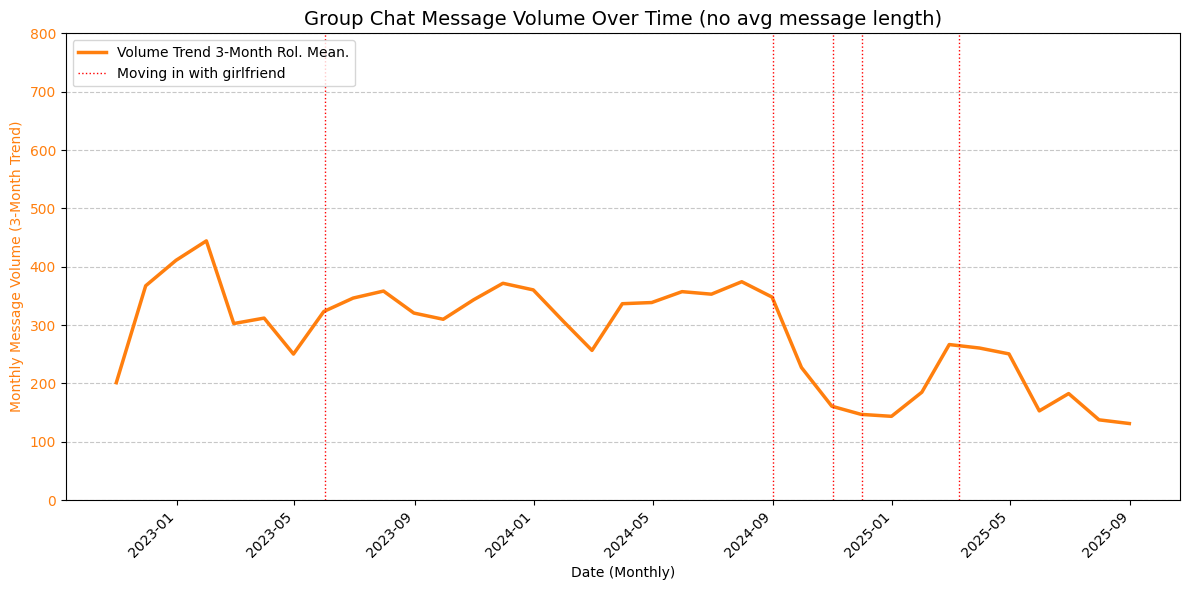

In [ ]:
def plot_volume_only(trends_df: pd.DataFrame, partnership_dates: pd.Series, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.figure
    color_volume = "#ff7f0e"
    ax.set_xlabel("Date (Monthly)")
    ax.set_ylabel("Monthly Message Volume (3-Month Trend)", color=color_volume)
    ax.plot(
        trends_df.index, trends_df["volume_trend"], color=color_volume,
        linewidth=2.5, lindestyle="-", label="Volume Trend 3-Month Rol. Mean."
    )
    ax.tick_params(axis="y", labelcolor=color_volume)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylim(0, 800)
    unique_dates = partnership_dates.dropna().unique()
    for i, date in enumerate(unique_dates):
        date_dt = pd.to_datetime(date)
        ax.axvline(x=date_dt, color="red", linestyle=":", linewidth=1.0,
                   label="Moving in with girlfriend" if i == 0 else "")
    ax.set_title("Group Chat Activity Declines After Sudden Moving In Together before 2025", fontsize=14)
    fig.autofmt_xdate(rotation=45)
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig

partnership_dates = df["date_living_with_partner"]
fig = plot_volume_only(trends_volume_only, partnership_dates)
plt.show()

#### Feedback:
This is the feedback i received (in dutch):
- Spurious correlation: De oranje lijn daalt, maar de rode lijnen zijn onduidelijk, eigenlijk alleen 2024-09 lijkt gecorreleerd met een drop van de oranje lijn. 
- Storyline: jouw verhaal is dat het intrekken de oorzaak is, maar ik zie maar 1 event 2024-09 dat een trendbreuk geeft, dus wat gebeurt er dan op al die andere rode lijnen?

#### To do:
- Spurious correlation: 
    - Treat moving in as an event, but the treatment is a permanent state
    - Fix: Use similarity -> Show the percentage with an increasing line of people living together to see this trend
- Preattentive processing:
    - The red lines are not clear to see what it means
        - Use a cumulative percentage line to make clear what you mean
- Gestalt principles:
    - Make a graph / box highlighting the events in a close time period
- Cleaner graph:
    - Use Jan-24 instead of months and number. 

In [12]:
from pathlib import Path

# Load from data/feature_added (same folder as timestamped whatsapp-*-features outputs)
feature_added_dir = Path("../data/feature_added").resolve()
csv_files = sorted(
    feature_added_dir.glob("whatsapp-*-features.csv"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not csv_files:
    raise FileNotFoundError(
        f"No whatsapp-*-features.csv in {feature_added_dir}. Run feature engineering first."
    )
latest_csv = csv_files[0]
print(f"Loading features from: {latest_csv}")
df = pd.read_csv(latest_csv, parse_dates=["timestamp", "date_living_with_partner"])

Loading features from: /Users/bas.hoogeventerink/Documents/Private/code/DAV/data/feature_added/whatsapp-20260323-213737-features.csv


In [13]:
df.head()

,timestamp,message,living_in_city,living_with_partner,date_living_with_partner,tech_background,author,year,month,week,...,drink_count,is_question,mentions_meet_up,is_image,is_empty_message,is_removed_message,has_emoji,emoji_count,sentiment_polarity,sentiment_category
0,2022-09-16 07:31:00+00:00,Wachten op dit bericht,1,1,2023-06-01 00:00:00+00:00,1,spattered-duck,2022,9,37,...,0,0,0,0,1,0,0,0,0.0,Neutral
1,2022-09-16 07:41:00+00:00,Wachten op dit bericht,0,0,NaT,1,riotous-dingo,2022,9,37,...,0,0,0,0,1,0,0,0,0.0,Neutral
2,2022-09-16 08:21:00+00:00,Wachten op dit bericht,0,1,2025-03-10 00:00:00+00:00,0,translucent-dog,2022,9,37,...,0,0,0,0,1,0,0,0,0.0,Neutral
3,2022-09-16 08:23:00+00:00,Wachten op dit bericht,0,1,2024-11-01 00:00:00+00:00,0,hypnotic-rabbit,2022,9,37,...,0,0,0,0,1,0,0,0,0.0,Neutral
4,2022-09-16 09:08:00+00:00,Wachten op dit bericht,0,0,NaT,1,crystalline-uakari,2022,9,37,...,0,0,0,0,1,0,0,0,0.0,Neutral


In [15]:
import pandas as pd

# Ensure timestamp column is in datetime format and extract year-month
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)

# 1. Volume of messages per month
volume_per_month = df.groupby("year_month")["message"].count().rename("message_volume")

# 2. Headcount living with partner by calendar month: unique authors with a known
# move-in month where that month is on or before the row's year_month (permanent state).
move_in_month = (
    df.drop_duplicates("author")
    .set_index("author")["date_living_with_partner"]
    .dt.to_period("M")
)
count_living_with_partner = pd.Series(
    {
        ym_str: int(
            ((move_in_month.notna()) & (move_in_month <= pd.Period(ym_str, freq="M"))).sum()
        )
        for ym_str in volume_per_month.index
    },
    name="count_living_with_partner",
).reindex(volume_per_month.index)

# Combine into a single table
summary_table = pd.concat([volume_per_month, count_living_with_partner], axis=1)
print(summary_table)

            message_volume  count_living_with_partner
year_month                                           
2022-09                 99                          0
2022-10                121                          0
2022-11                384                          0
2022-12                597                          0
2023-01                252                          0
2023-02                484                          0
2023-03                172                          0
2023-04                280                          0
2023-05                299                          0
2023-06                390                          1
2023-07                349                          1
2023-08                335                          1
2023-09                278                          1
2023-10                317                          1
2023-11                435                          1
2023-12                363                          1
2024-01                283  

/var/folders/40/vmrkk6n56lxcnq2mt9w6mtbm0000gp/T/ipykernel_63626/1517599923.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)
/var/folders/40/vmrkk6n56lxcnq2mt9w6mtbm0000gp/T/ipykernel_63626/1517599923.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


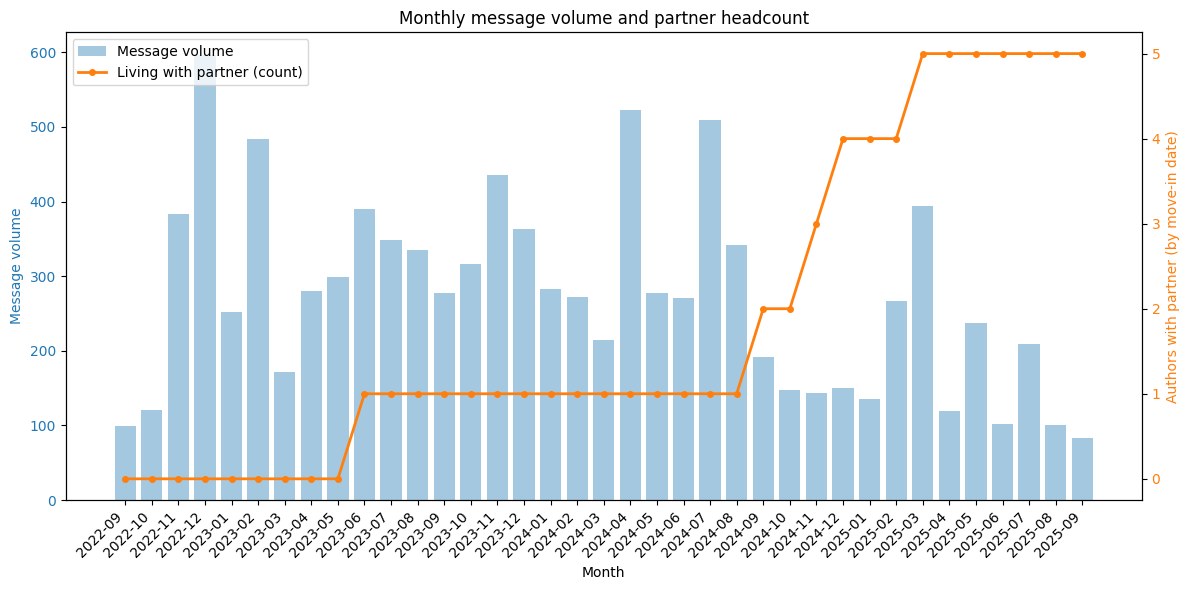

In [17]:
# Visualize summary_table: volume (bars) vs. partner headcount (line)
plot_df = summary_table.sort_index()
xpos = list(range(len(plot_df)))

fig, ax1 = plt.subplots(figsize=(12, 6))
color_vol, color_cnt = "tab:blue", "tab:orange"

ax1.bar(xpos, plot_df["message_volume"], color=color_vol, alpha=0.4, label="Message volume")
ax1.set_ylabel("Message volume", color=color_vol)
ax1.tick_params(axis="y", labelcolor=color_vol)
ax1.set_xlabel("Month")
step = max(1, len(xpos) // 24)
ax1.set_xticks(xpos[::step])
ax1.set_xticklabels(plot_df.index[::step], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(
    xpos,
    plot_df["count_living_with_partner"],
    color=color_cnt,
    marker="o",
    linewidth=2,
    markersize=4,
    label="Living with partner (count)",
)
ax2.set_ylabel("Authors with partner (by move-in date)", color=color_cnt)
ax2.tick_params(axis="y", labelcolor=color_cnt)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left")
plt.title("Monthly message volume and partner headcount")
plt.tight_layout()
plt.show()

## Dual-axis plot (original: volume + avg word count)

For comparison: same as the script output with both message volume and average word count.

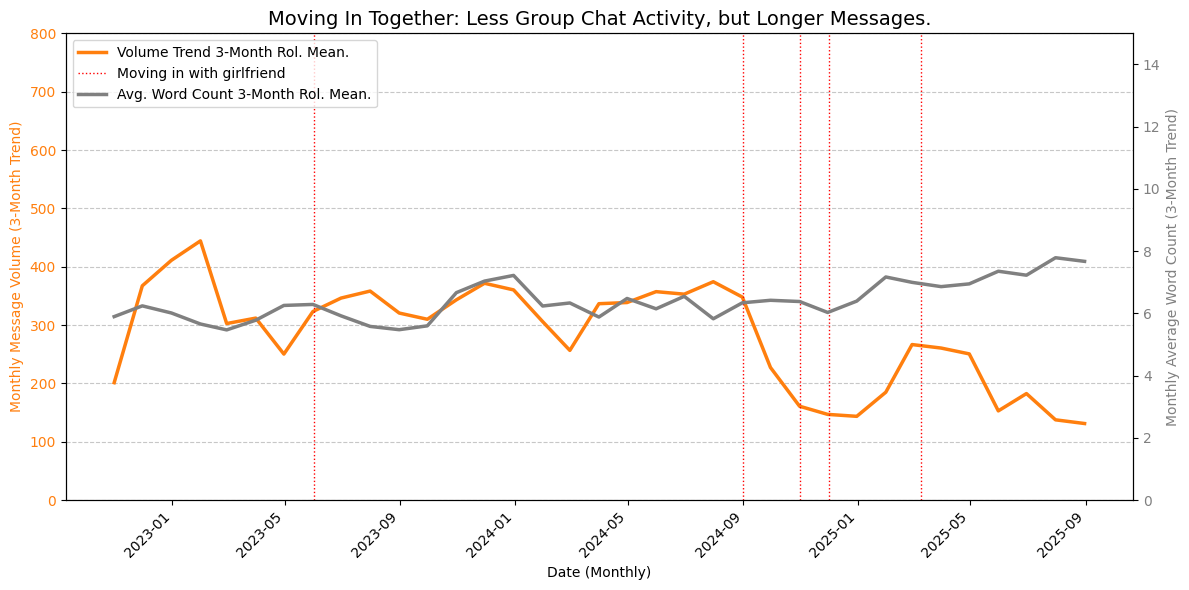

In [7]:
def plot_dual_axis(trends_df: pd.DataFrame, partnership_dates: pd.Series, ax1=None):
    if ax1 is None:
        fig, ax1 = plt.subplots(figsize=(12, 6))
    else:
        fig = ax1.figure
    color_volume, color_words = "#ff7f0e", "#808080"
    ax1.set_xlabel("Date (Monthly)")
    ax1.set_ylabel("Monthly Message Volume (3-Month Trend)", color=color_volume)
    ax1.plot(trends_df.index, trends_df["volume_trend"], color=color_volume, linewidth=2.5, linestyle="-",
            label="Volume Trend 3-Month Rol. Mean.")
    ax1.tick_params(axis="y", labelcolor=color_volume)
    ax1.grid(axis="y", linestyle="--", alpha=0.7)
    ax1.set_ylim(0, 800)
    ax2 = ax1.twinx()
    ax2.set_ylabel("Monthly Average Word Count (3-Month Trend)", color=color_words)
    ax2.plot(trends_df.index, trends_df["word_count_trend"], color=color_words, linewidth=2.5, linestyle="-",
            label="Avg. Word Count 3-Month Rol. Mean.")
    ax2.tick_params(axis="y", labelcolor=color_words)
    ax2.set_ylim(0, 15)
    unique_dates = partnership_dates.dropna().unique()
    for i, date in enumerate(unique_dates):
        date_dt = pd.to_datetime(date)
        ax1.axvline(x=date_dt, color="red", linestyle=":", linewidth=1.0,
                   label="Moving in with girlfriend" if i == 0 else "")
    plt.title("Moving In Together: Less Group Chat Activity, but Longer Messages.", fontsize=14)
    fig.autofmt_xdate(rotation=45)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    fig.tight_layout()
    return fig

fig = plot_dual_axis(trends_full, partnership_dates)
plt.show()